In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from textProcessing import textProcessing
import nltk
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
import string
from collections import Counter
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

In [2]:
df = pd.read_csv("housing_crisis_nlp_data.csv")
display(df)

,Video_ID,User,Text,Date,Likes,Is_Reply
0,vWlh41jJ2Ww,@davidwalden2887,The housing shortage in Australia will be imme...,2026-05-16T13:44:12Z,0,False
1,vWlh41jJ2Ww,@ColdPatterns,My last neighbour was a single 65 year old guy...,2026-02-22T17:48:56Z,0,False
2,vWlh41jJ2Ww,@StephP2025,We should all go back to where we came from. S...,2026-01-30T14:50:16Z,0,False
3,vWlh41jJ2Ww,@bull13__x,Bitcoin fixes this,2026-01-15T21:23:02Z,0,False
4,vWlh41jJ2Ww,@joebullwinkle5099,The systemic failure in housing is that the is...,2026-01-01T19:46:16Z,0,False
...,...,...,...,...,...,...
21071,RJDVeLa7uXg,@U.s.e.r.3493,Immigrants arent the majority buying houses......,2026-03-26T07:21:58Z,0,True
21072,RJDVeLa7uXg,@offcut7167,Australia has a lot of resources and big oppor...,2026-03-26T08:31:58Z,0,True
21073,RJDVeLa7uXg,@U.s.e.r.3493,​@offcut7167ah so you're saying that even if w...,2026-03-26T09:15:35Z,1,True
21074,RJDVeLa7uXg,@offcut7167,​​@U.s.e.r.3493Yeah two tiered society. The ol...,2026-03-26T09:27:48Z,2,True


In [3]:
tweetTokenizer = TweetTokenizer()
lPunct = list(string.punctuation)
lStopwords = stopwords.words('english') + lPunct + ['rt', 'via', '...', '…', '"', "'", '`', '’', '”', '—', '°', '“', '..', ':', '::']
processor = textProcessing(tweetTokenizer, lStopwords)
df['Text'] = df['Text'].fillna('').astype(str)
df['processedTokens'] = df['Text'].apply(processor.processText)
df['halfProcessedTokens'] = df['Text'].apply(processor.halfPreprocessText)

preUniqueWords = processor.returnUniqueWords(df, 'halfProcessedTokens')
postUniqueWords = processor.returnUniqueWords(df, 'processedTokens')
print(preUniqueWords.most_common(20))
print(postUniqueWords.most_common(20))

[('.', 38295), ('the', 30809), (',', 23847), ('to', 21999), ('and', 18044), ('a', 16288), ('of', 13235), ('is', 12517), ('in', 12197), ('for', 8364), ('that', 7323), ('are', 7220), ('it', 6678), ('I', 6644), ('you', 6295), ('have', 5269), ('on', 5026), ('they', 4955), ('’', 4869), ('be', 4798)]
[('people', 4658), ('housing', 4288), ('government', 3032), ('house', 2802), ('australia', 2542), ('would', 2461), ('prices', 2218), ('like', 2210), ('get', 2113), ('property', 2049), ('home', 1882), ('immigration', 1853), ('one', 1837), ('money', 1797), ('years', 1692), ('houses', 1691), ('need', 1584), ('tax', 1569), ('going', 1489), ('buy', 1460)]


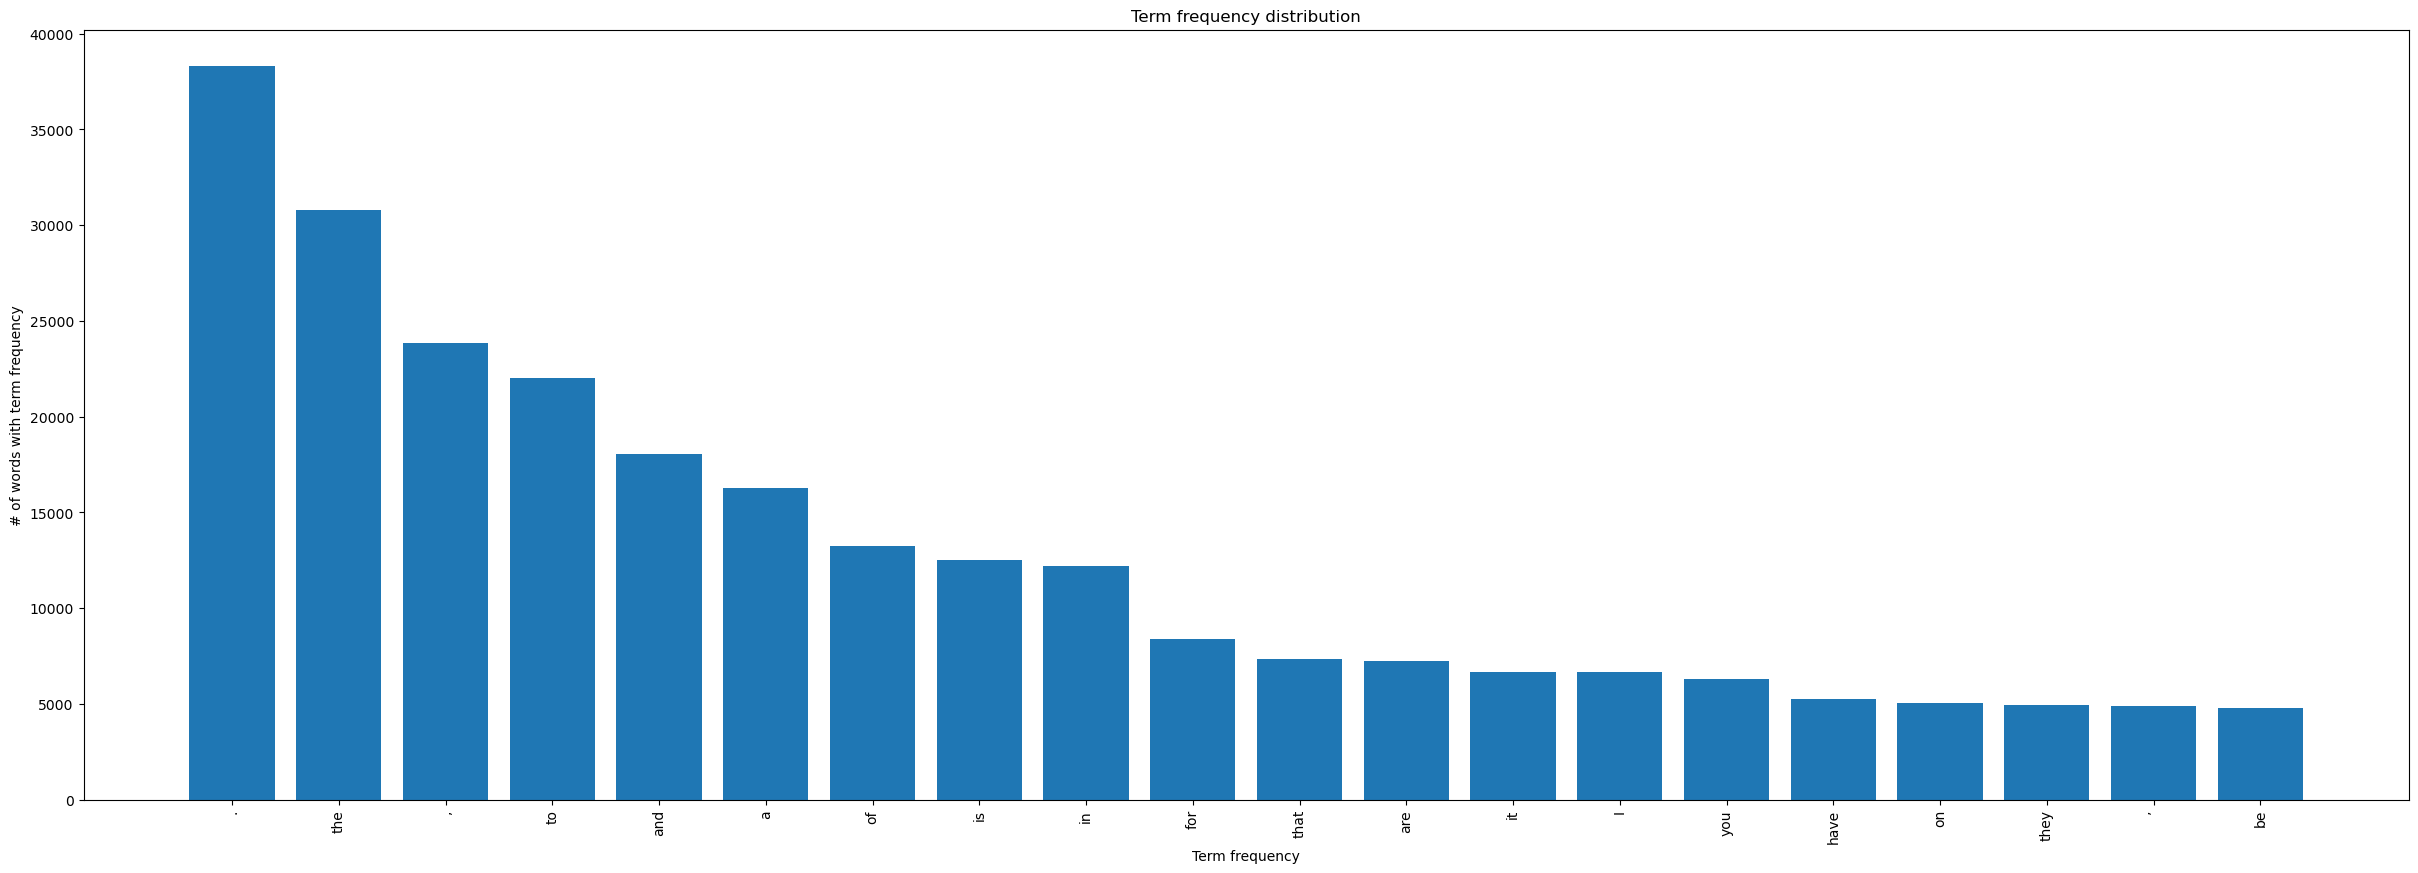

In [4]:

processor.outputGraphWordFreq(preUniqueWords, 20)

Word frequency before processing

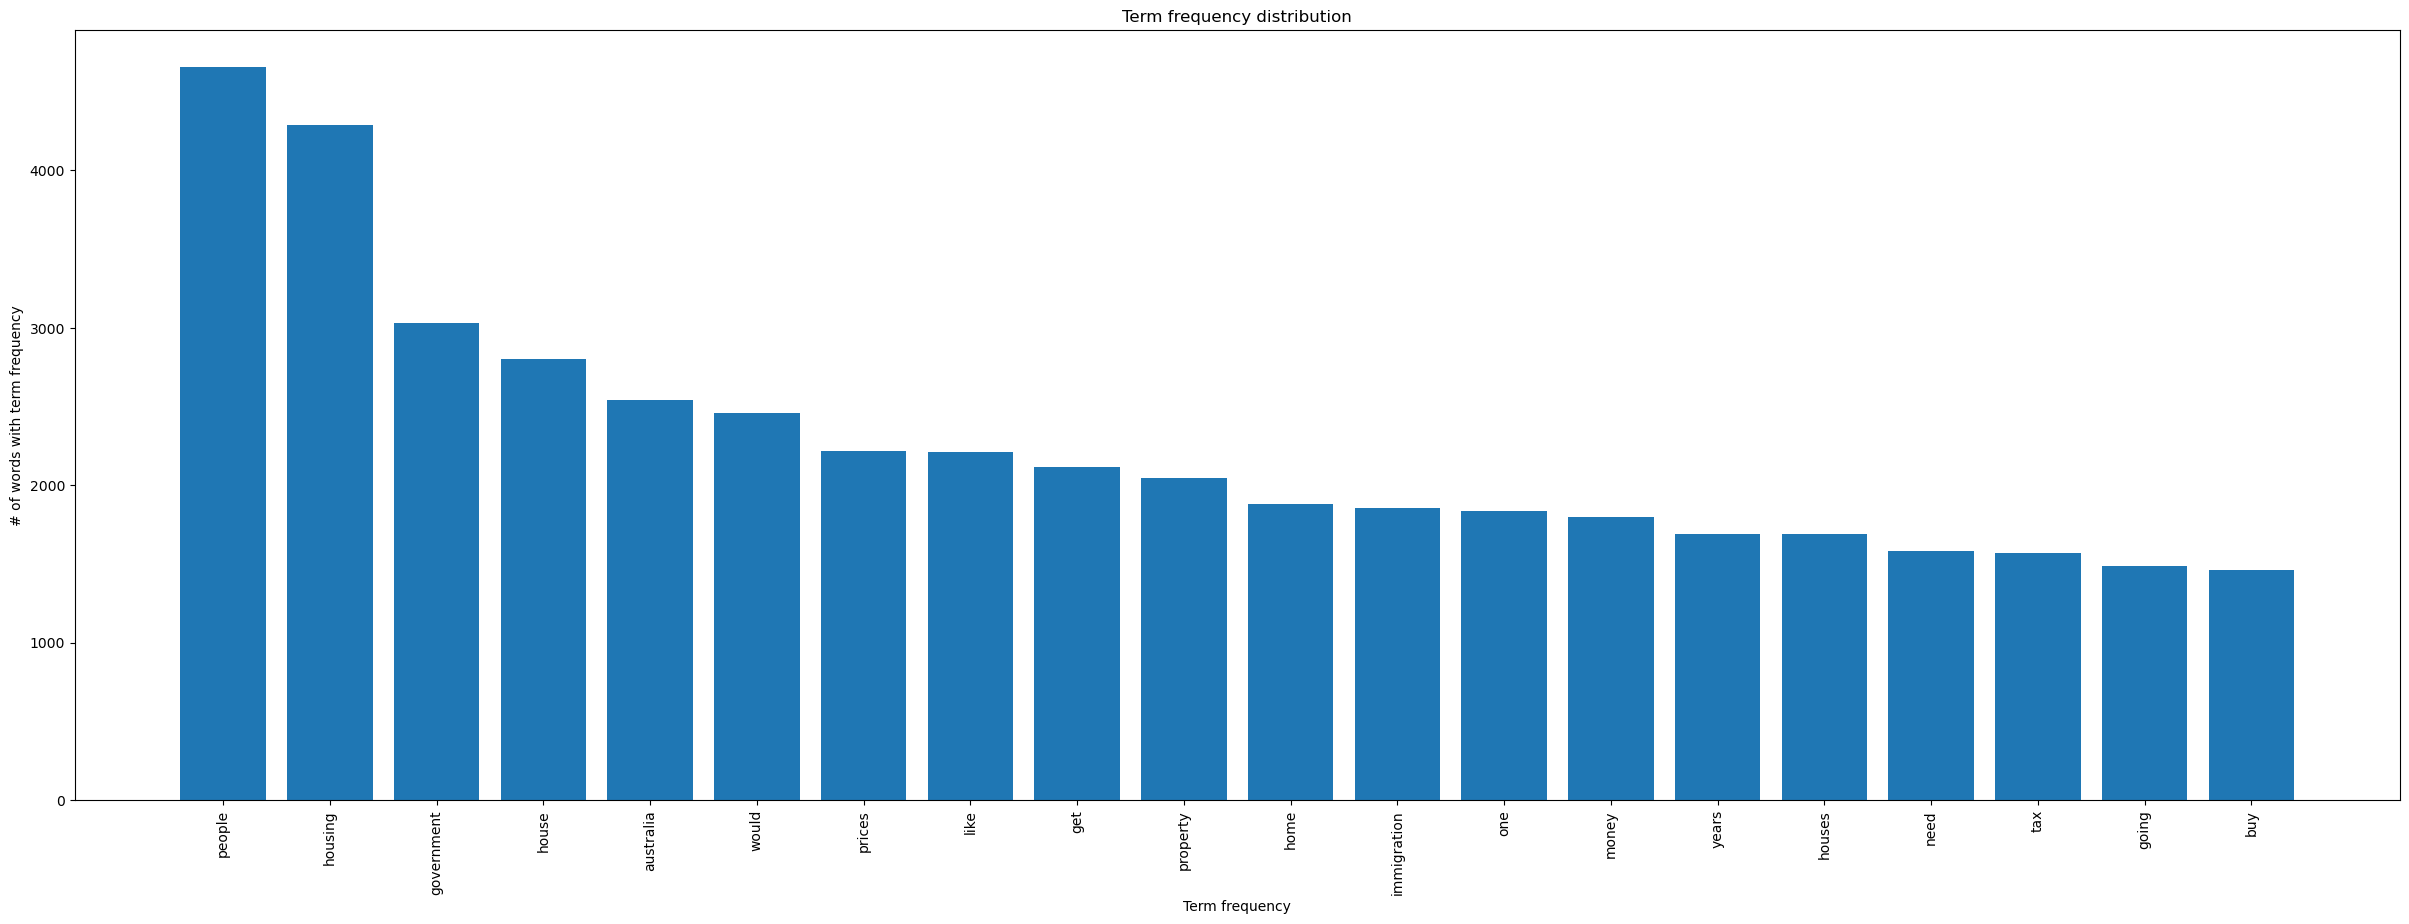

In [5]:
processor.outputGraphWordFreq(postUniqueWords, 20)

Word frequency after processing

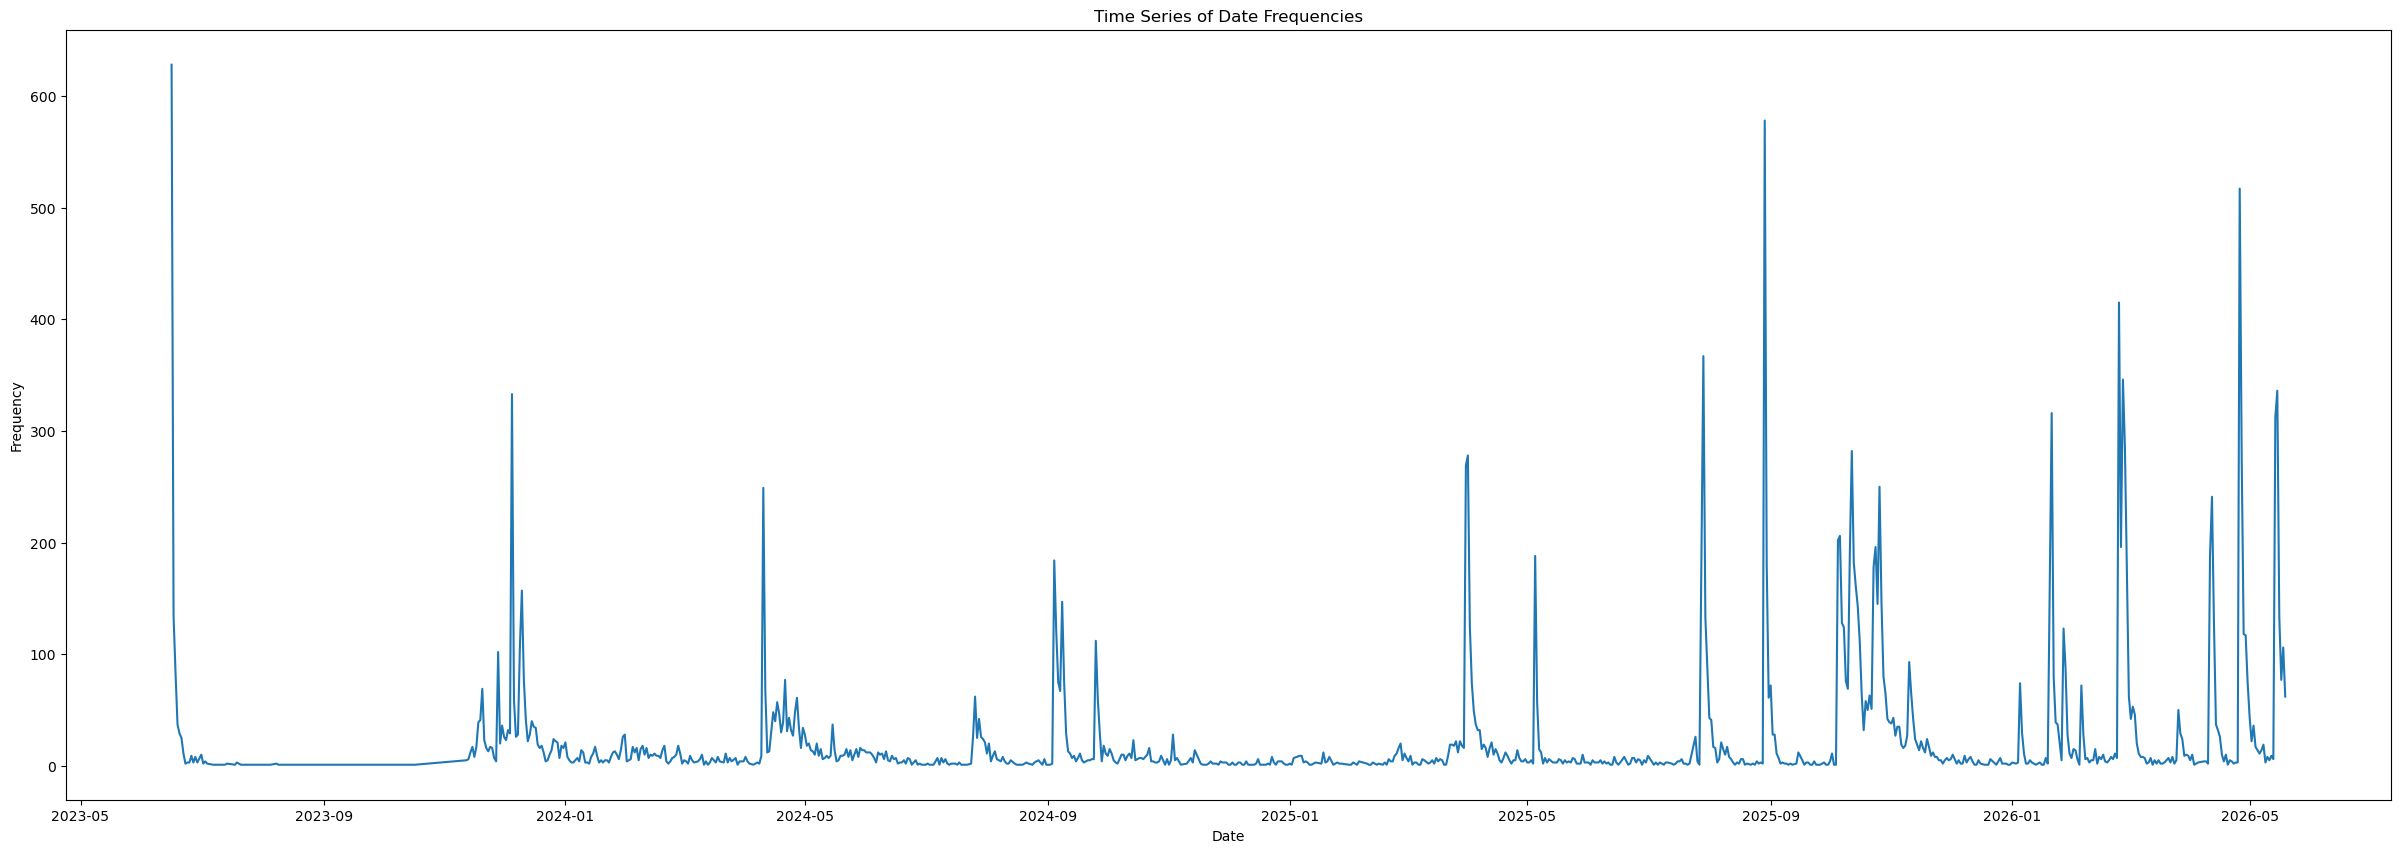

In [6]:
processor.outputGraphTimeSeries(df)

Time series graph of comments

In [7]:
dfAnalysed = pd.read_csv("housing_crisis_nlp_analysed.csv")
display(dfAnalysed)



,Video_ID,User,Text,Date,Likes,Is_Reply,Topic_Cluster,Predominant_Emotion
0,vWlh41jJ2Ww,@davidwalden2887,The housing shortage in Australia will be imme...,2026-05-16T13:44:12Z,0,False,-1,neutral
1,vWlh41jJ2Ww,@ColdPatterns,My last neighbour was a single 65 year old guy...,2026-02-22T17:48:56Z,0,False,-1,neutral
2,vWlh41jJ2Ww,@StephP2025,We should all go back to where we came from. S...,2026-01-30T14:50:16Z,0,False,-1,neutral
3,vWlh41jJ2Ww,@bull13__x,Bitcoin fixes this,2026-01-15T21:23:02Z,0,False,-1,neutral
4,vWlh41jJ2Ww,@joebullwinkle5099,The systemic failure in housing is that the is...,2026-01-01T19:46:16Z,0,False,8,neutral
...,...,...,...,...,...,...,...,...
21069,RJDVeLa7uXg,@U.s.e.r.3493,Immigrants arent the majority buying houses......,2026-03-26T07:21:58Z,0,True,2,neutral
21070,RJDVeLa7uXg,@offcut7167,Australia has a lot of resources and big oppor...,2026-03-26T08:31:58Z,0,True,-1,neutral
21071,RJDVeLa7uXg,@U.s.e.r.3493,​@offcut7167ah so you're saying that even if w...,2026-03-26T09:15:35Z,1,True,145,neutral
21072,RJDVeLa7uXg,@offcut7167,​​@U.s.e.r.3493Yeah two tiered society. The ol...,2026-03-26T09:27:48Z,2,True,-1,neutral


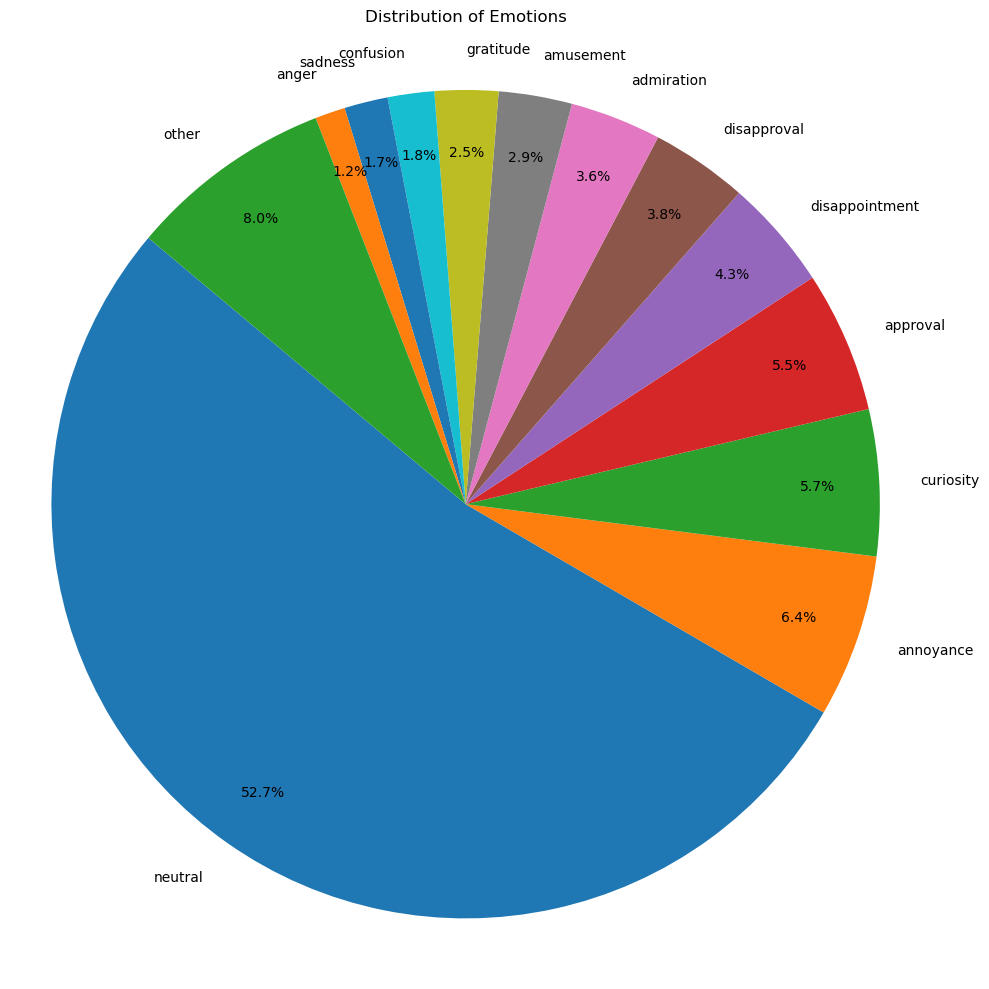

In [8]:
processor.outputGraphEmotionPieChart(dfAnalysed, 12)

Emotions/Sentiment analysis of comments

In [9]:
communities = pd.read_csv("video_community_analysis.csv")
communityArr = []

for _, row in communities.iterrows():
    currIds = row['Videos']
    communityArr.append([row['Community_ID'], currIds.split('; ')])
    

In [10]:
def getCommunity(Video_ID, communityArr):
    for commId, vids in communityArr:
        if Video_ID in vids:
            return commId
    return -1
    
dfAnalysed['Community_ID'] = dfAnalysed['Video_ID'].apply(lambda vid: getCommunity(vid, communityArr))
comm0 = dfAnalysed[dfAnalysed['Community_ID'] == 0]
comm1 = dfAnalysed[dfAnalysed['Community_ID'] == 1]
comm2 = dfAnalysed[dfAnalysed['Community_ID'] == 2]

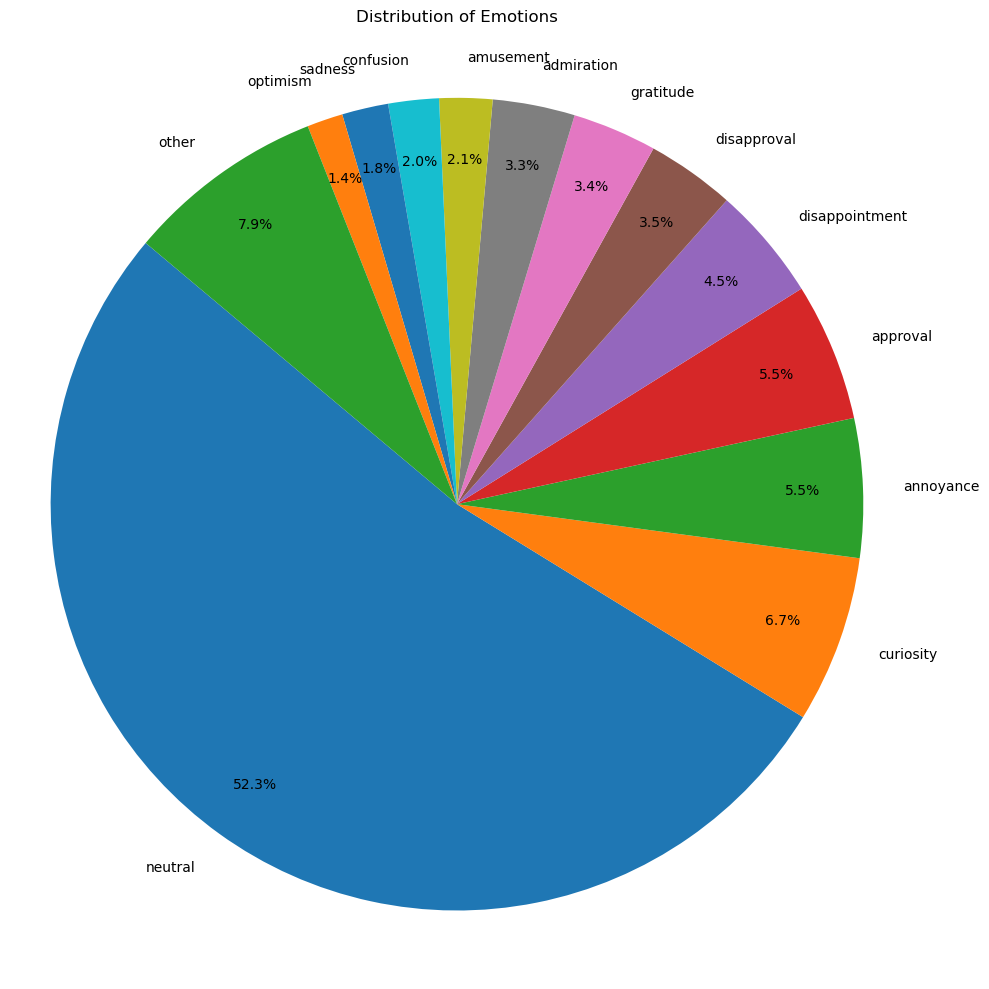

In [11]:
processor.outputGraphEmotionPieChart(comm0, 12)

Community zero sentiment analysis

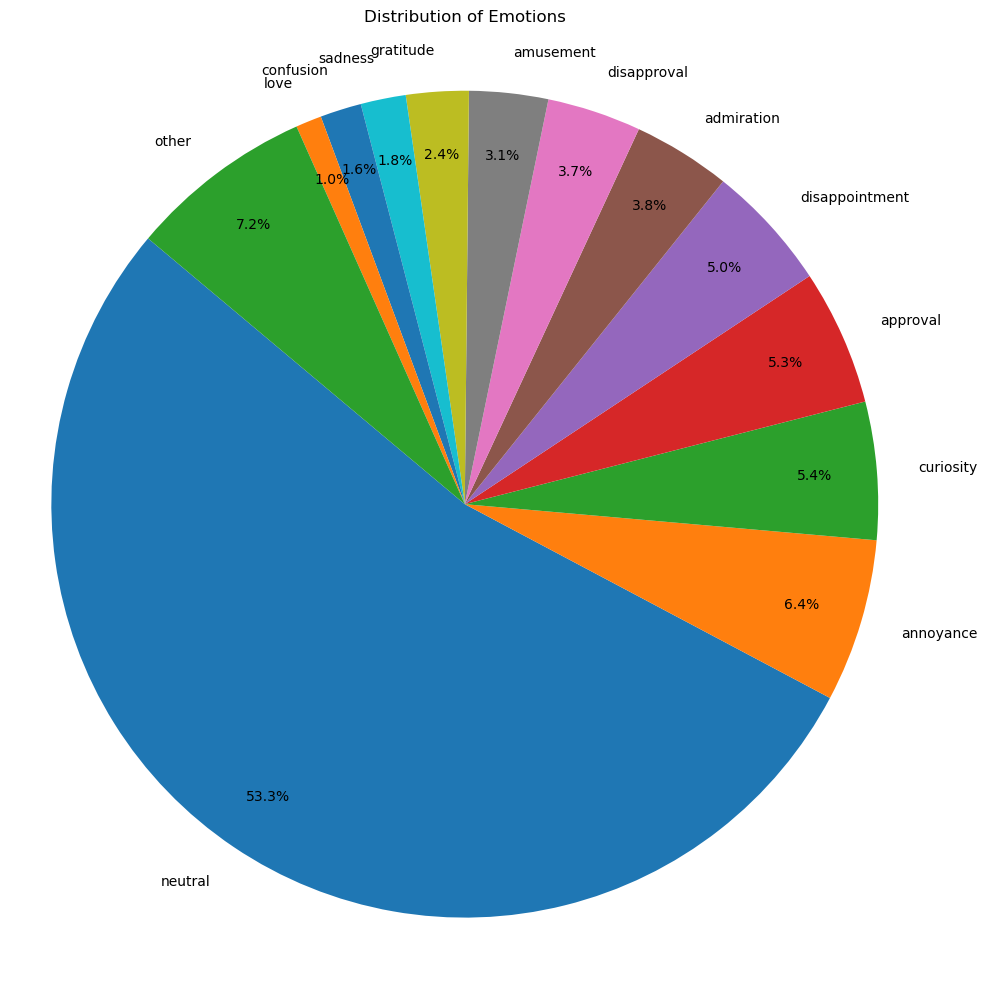

In [12]:
processor.outputGraphEmotionPieChart(comm1, 12)

community 1 sentiment analysis

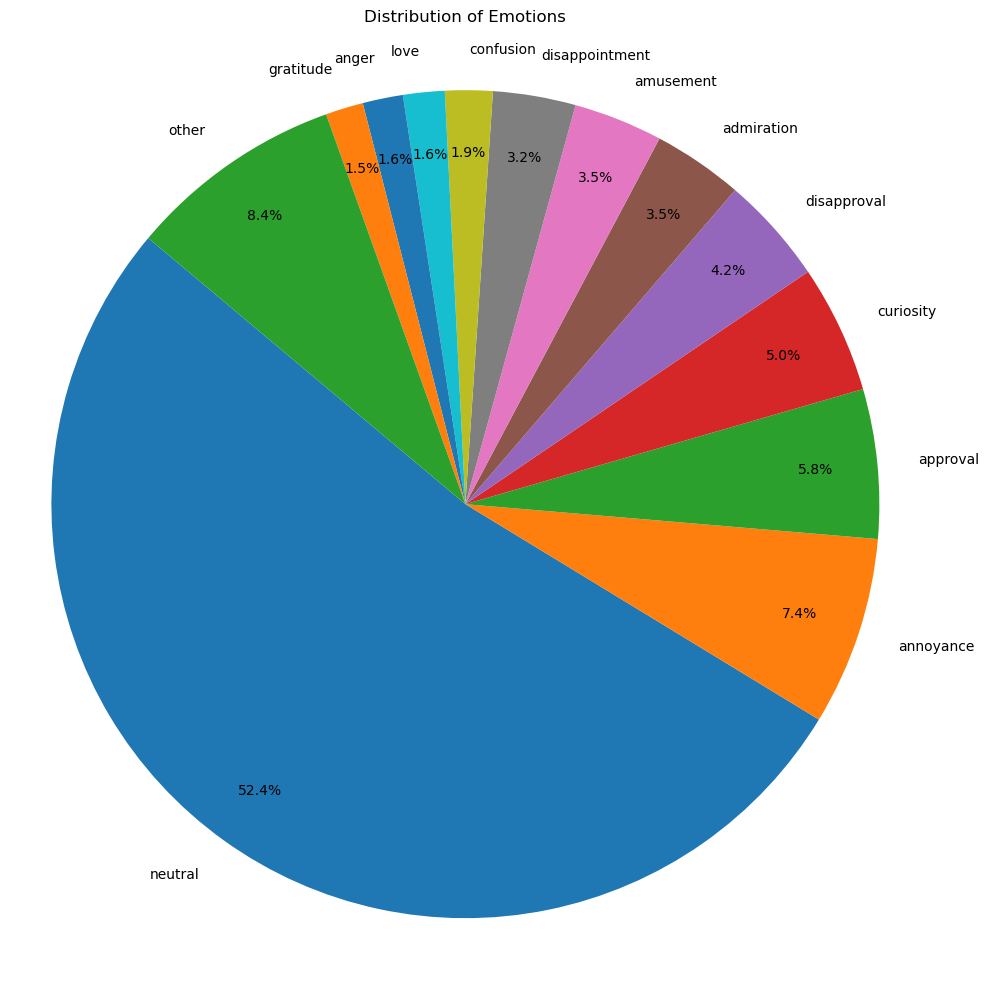

In [13]:
processor.outputGraphEmotionPieChart(comm2, 12)

community 2 sentiment analysis

Topic 1:
people labor government like australia going housing country good greens know think money video time right great got years want
Topic 2:
people immigration houses housing live house australia new need build like living want year buy problem high rent work building
Topic 3:
property housing prices tax house home market land government investment money properties investors pay negative buy years gearing real rates


c:\Users\callu\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


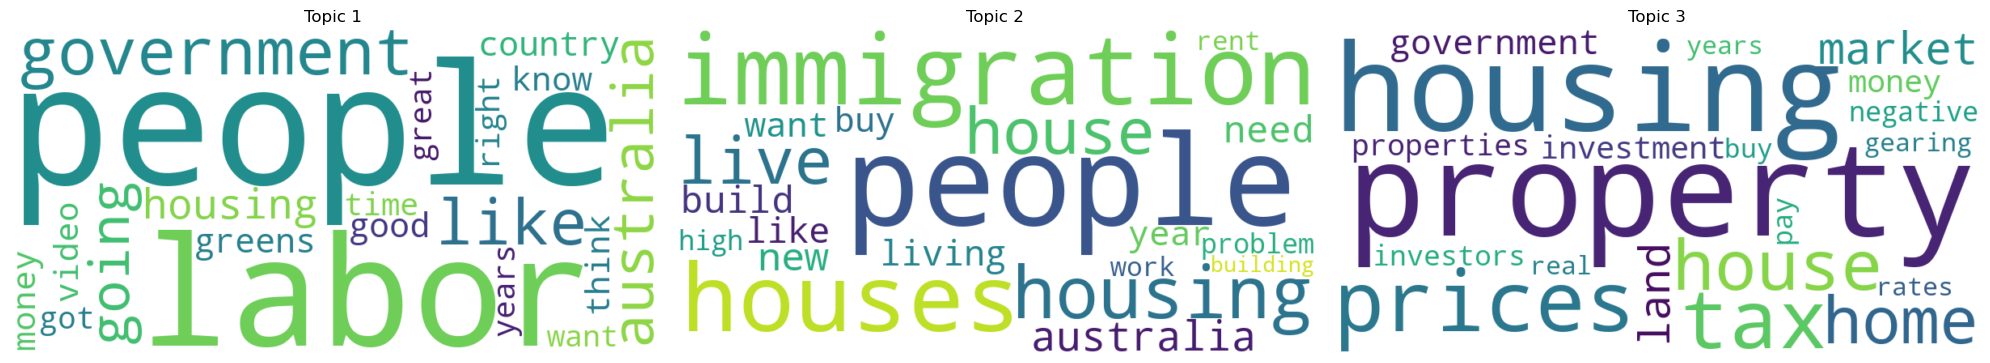

In [14]:
processor.getLDAModel(df, 3, 20, 1500)

Generates code and LDA visulisation html file